<a href="https://colab.research.google.com/github/jane-rusakova/python_for_hw_tasks/blob/main/HW_16_1_%D0%9F%D1%80%D0%BE%D0%B3%D0%BD%D0%BE%D0%B7%D1%83%D0%B2%D0%B0%D0%BD%D0%BD%D1%8F_%D0%BE%D1%80%D0%B5%D0%BD%D0%B4%D0%BD%D0%BE%D1%97_%D0%BF%D0%BB%D0%B0%D1%82%D0%B8_%D0%B7%D0%B0_%D0%B6%D0%B8%D1%82%D0%BB%D0%BE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Прогнозування орендної плати за житло

## Мета завдання
Застосувати знання з лекції для побудови моделі лінійної регресії, що прогнозує орендну плату за житло в Індії. Ви пройдете весь цикл вирішення задачі машинного навчання: від дослідницького аналізу до оцінки якості моделі.

## Опис датасету
**House Rent Prediction Dataset** містить інформацію про 4700+ оголошень про оренду житла в Індії з такими параметрами:
- **BHK**: Кількість спалень, залів, кухонь
- **Rent**: Орендна плата (цільова змінна)
- **Size**: Площа в квадратних футах
- **Floor**: Поверх та загальна кількість поверхів
- **Area Type**: Тип розрахунку площі
- **Area Locality**: Район
- **City**: Місто
- **Furnishing Status**: Стан меблювання
- **Tenant Preferred**: Тип орендаря
- **Bathroom**: Кількість ванних кімнат
- **Point of Contact**: Контактна особа

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `House_Rent_Dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (включно з типами даних та кількістю значень)


In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("House_Rent_Dataset.csv")

In [3]:
df.shape


(4746, 12)

In [4]:
df.head()


,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


In [6]:
df.describe()


,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


## Завдання 2: Дослідницький аналіз даних (EDA) (5 балів)

**Що потрібно зробити:**
1. **Аналіз пропущених значень.** Перевірте наявність і відсоток пропущених значень у кожній колонці
2. **Базова статистика.** Обчисліть базову статистику (середнє, квартилі, стандартне відхилення) для числових змінних.
3. **Аналіз цільової змінної.** Побудуйте гістограму розподілу цільової змінної (Rent)
4. **Робота з викидами.** Знайдіть та видаліть викиди в цільовій змінній (якщо є). Визначити викиди можна будь-яким зрозумілим для вас способом, як варіант - таким, що використовується в побудові box-plot (https://en.wikipedia.org/wiki/Box_plot#Example_with_outliers).
5. **Аналіз категоріальних змінних.** Виведіть кількість унікальних значень для кожної з категоріальних колонок.


In [7]:
# Кількість пропущених значень
missing_values = df.isnull().sum()

# Відсоток пропущених значень
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percent
})

missing_df


,Missing Values,Percentage (%)
Posted On,0,0.0
BHK,0,0.0
Rent,0,0.0
Size,0,0.0
Floor,0,0.0
Area Type,0,0.0
Area Locality,0,0.0
City,0,0.0
Furnishing Status,0,0.0
Tenant Preferred,0,0.0


In [10]:
df.describe()


,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


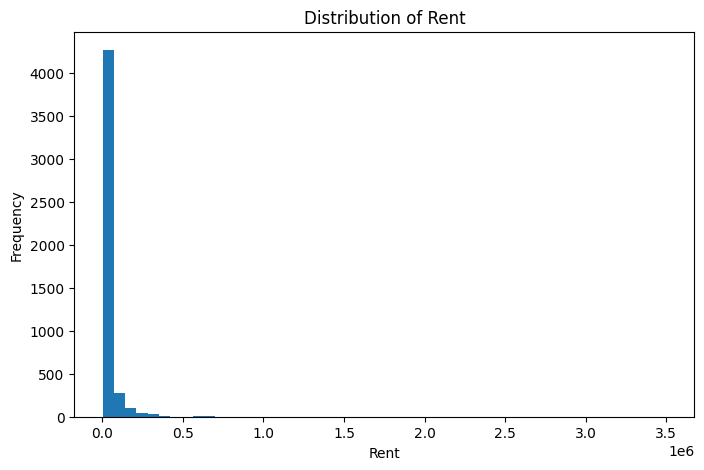

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['Rent'], bins=50)
plt.xlabel("Rent")
plt.ylabel("Frequency")
plt.title("Distribution of Rent")
plt.show()


In [12]:
Q1 = df['Rent'].quantile(0.25)
Q3 = df['Rent'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Кількість викидів
outliers = df[(df['Rent'] < lower_bound) | (df['Rent'] > upper_bound)]
print("Кількість викидів:", len(outliers))


Кількість викидів: 520


In [13]:
df_clean = df[(df['Rent'] >= lower_bound) & (df['Rent'] <= upper_bound)]

print("Розмір датасету після видалення:", df_clean.shape)


Розмір датасету після видалення: (4226, 12)


In [14]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} унікальних значень")


Posted On: 81 унікальних значень
Floor: 480 унікальних значень
Area Type: 3 унікальних значень
Area Locality: 2235 унікальних значень
City: 6 унікальних значень
Furnishing Status: 3 унікальних значень
Tenant Preferred: 3 унікальних значень
Point of Contact: 3 унікальних значень



## Завдання 3: Аналіз кореляцій та взаємозв'язків (3 бали)

**Що потрібно зробити:**
1. Обчисліть матрицю кореляцій для числових змінних
2. Візуалізуйте кореляційну матрицю за допомогою heatmap
3. Побудуйте scatter plot між Size та Rent
4. Проаналізуйте взаємозв'язок між BHK та Rent за допомогою boxplot (який розподіл плати для різних значень BHK)


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# вибираємо числові колонки
numeric_df = df_clean.select_dtypes(include=['int64', 'float64'])

# матриця кореляцій
corr_matrix = numeric_df.corr()

corr_matrix


,BHK,Rent,Size,Bathroom
BHK,1.000000,0.401268,0.698453,0.747918
Rent,0.401268,1.000000,0.393605,0.506528
Size,0.698453,0.393605,1.000000,0.680607
Bathroom,0.747918,0.506528,0.680607,1.000000


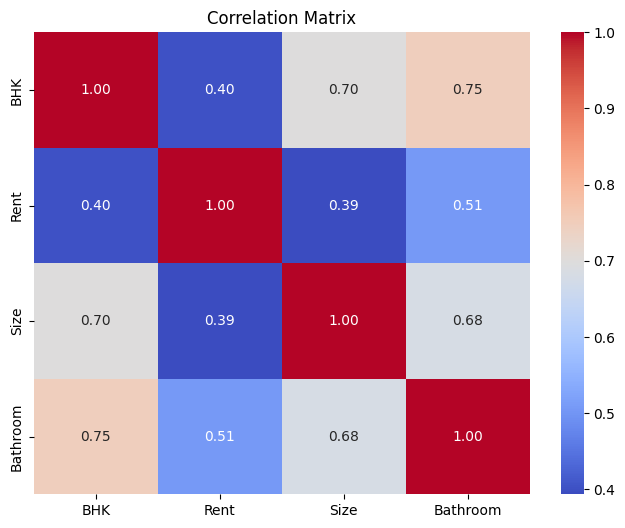

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

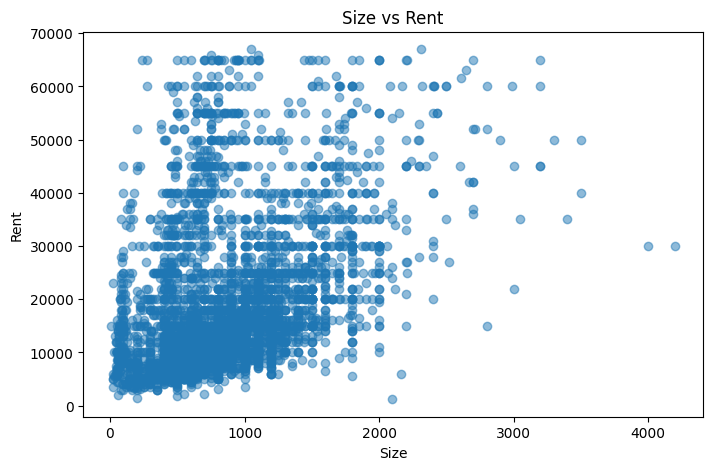

In [17]:
plt.figure(figsize=(8,5))
plt.scatter(df_clean['Size'], df_clean['Rent'], alpha=0.5)
plt.xlabel("Size")
plt.ylabel("Rent")
plt.title("Size vs Rent")
plt.show()

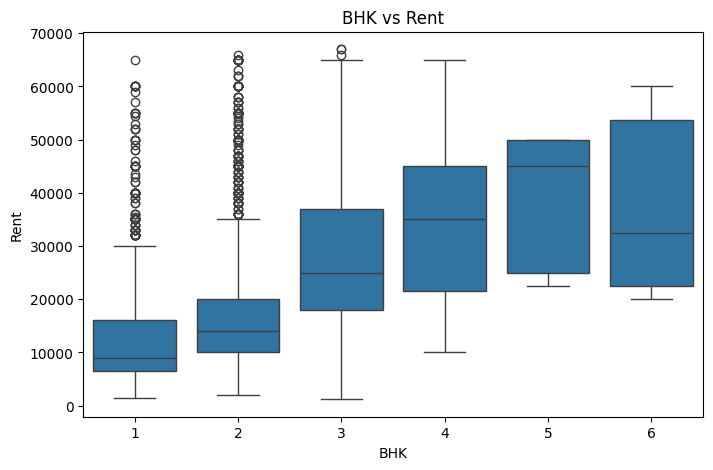

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x='BHK', y='Rent', data=df_clean)
plt.title("BHK vs Rent")
plt.show()

## Завдання 4: Feature Engineering та підготовка даних (4 бали)

**Що потрібно зробити:**
1. Закодуйте категоріальні змінні за допомогою One-Hot Encoding. Пригадайте, що в лекції ми говорили щодо кодування кат. змінних з великої кількістю різних значень і як працювати з такими випадками. Ви можете закодувати не всі кат. змінні, а лише ті, що вважаєте за потрібні (скажімо ті, що мають відносно небагато різних значень).
2. **Опціонально (по 0.5 бала за кожну доцільну ознаку):** Додайте нові ознаки, обчислені на основі наявних даних, які б на ваш погляд були корисними для моделі
3. Виберіть ознаки для побудови моделі (виключіть непотрібні колонки). Виключити можна, наприклад, ті колонки, які мають категоріальний тип і забагато (більше 20) різних значень. Треба виключити хоча б 1 колонку.
4. Розділіть дані на ознаки (X) та цільову змінну (y)
5. Застосуйте стандартизацію до числових ознак


In [19]:
df_clean.select_dtypes(include='object').nunique()

,0
Posted On,80
Floor,340
Area Type,3
Area Locality,1997
City,6
Furnishing Status,3
Tenant Preferred,3
Point of Contact,3


Виключаємо (висока кардинальність):

Area Locality

Floor

In [23]:
df_clean['Rent_per_sqft'] = df_clean['Rent'] / df_clean['Size']

In [24]:
df_model = df_clean.drop(columns=['Area Locality', 'Floor'])

In [25]:
categorical_cols = ['Area Type', 'City', 'Furnishing Status',
                    'Tenant Preferred', 'Point of Contact']

df_model = pd.get_dummies(df_model,
                          columns=categorical_cols,
                          drop_first=True)

In [26]:
X = df_model.drop('Rent', axis=1)
y = df_model['Rent']

In [27]:
X = df_model.drop('Rent', axis=1)
y = df_model['Rent']

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns

X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

## Завдання 5: Розділення даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на навчальну (80%) та тестову (20%) вибірки.
2. Створіть модель лінійної регресії.
3. Навчіть модель на навчальних даних.
4. Виведіть усі коефіцієнти моделі (ваги) та напишіть, які 2 ознаки найбільше впливають на прогноз.
5. Зробіть прогнози на тренувальній та тестовій вибірках.

In [29]:
from sklearn.model_selection import train_test_split

X = df_model.drop('Rent', axis=1)
y = df_model['Rent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# fit тільки на train
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# transform test
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [33]:
df_model = df_model.drop(columns=['Posted On'])

In [34]:
X = df_model.drop('Rent', axis=1)
y = df_model['Rent']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)

coefficients


,Feature,Coefficient
10,City_Mumbai,16018.486318
16,Point of Contact_Contact Owner,-7864.507136
12,Furnishing Status_Unfurnished,-3723.603989
15,Point of Contact_Contact Builder,-3692.179144
5,Area Type_Super Area,-3521.690092
4,Area Type_Carpet Area,-3100.628593
11,Furnishing Status_Semi-Furnished,-3021.918131
8,City_Hyderabad,-2923.424033
9,City_Kolkata,-2679.783604
0,BHK,2201.629175


In [40]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

## Завдання 6: Оцінка якості моделі (2 бали)

**Що потрібно зробити:**
1. Обчисліть MAE, RMSE та R² для навчальної та тестової вибірок
2. Порівняйте метрики та зробіть висновок про якість моделі
3. Проаналізуйте і дайте висновок, чи є ознаки перенавчання або недонавчання (**Нагадування**: перенавчання - коли модель дуже добре працює на тренувальних даних, але погано на тестових; недонавчання - коли модель погано працює навіть на тренувальних даних)
4. Побудуйте графік розсіювання "реальні vs прогнозовані значення" та зробіть висновок про якість моделі


In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [42]:
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

In [43]:
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

In [44]:
print("TRAIN METRICS")
print("MAE:", mae_train)
print("RMSE:", rmse_train)
print("R2:", r2_train)

print("\nTEST METRICS")
print("MAE:", mae_test)
print("RMSE:", rmse_test)
print("R2:", r2_test)

TRAIN METRICS
MAE: 5065.047766222969
RMSE: 7055.233345736017
R2: 0.7392746977601904

TEST METRICS
MAE: 5124.847233799342
RMSE: 8451.131695049975
R2: 0.6275108587072038


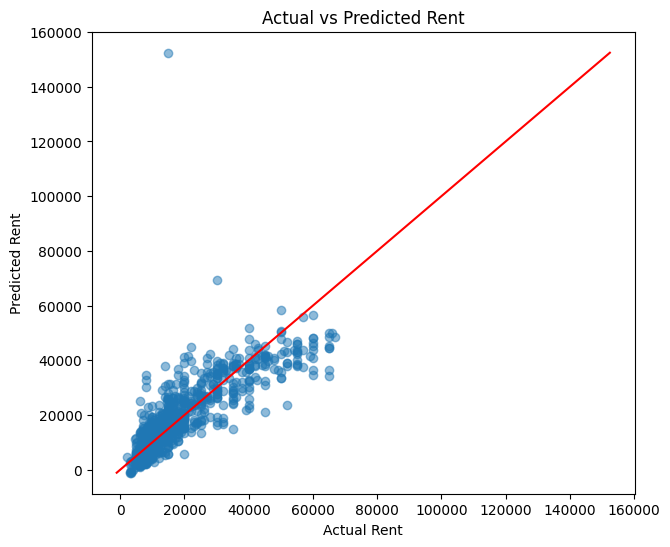

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.title("Actual vs Predicted Rent")

# Додаємо ідеальну лінію
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red')

plt.show()

## Завдання 7: Аналіз помилок (4 бали)

**Що потрібно зробити:**
1. Обчисліть помилки (residuals = реальні - прогнозовані значення)
2. Побудуйте гістограму розподілу помилок
3. Створіть scatter plot помилок відносно величини прогнозованих значень. Чи росте помилка з ростом прогнозованого значення?
4. Знайдіть 5 прогнозів з найбільшими помилками
5. Проаналізуйте, на яких типах житла модель помиляється найбільше. Типи можна розрізняти за кількістю кімнат чи містом, наприклад.
6. Подумайте і напишіть, які наступні кроки ви б зробили, аби поліпшити якість моделі. Опціонально можна їх зробити і ми перевіримо :)

In [47]:
residuals = y_test - y_test_pred

In [48]:
residuals.head()

,Rent
1998,-6761.582219
3190,2281.649419
2670,-1728.125987
4647,5618.525158
4488,192.715198


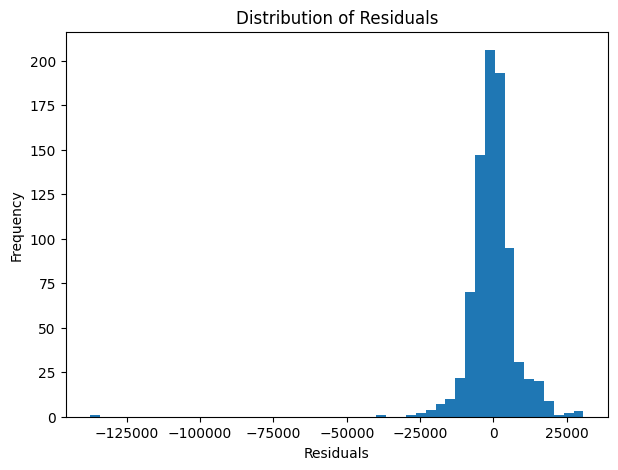

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.hist(residuals, bins=50)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()

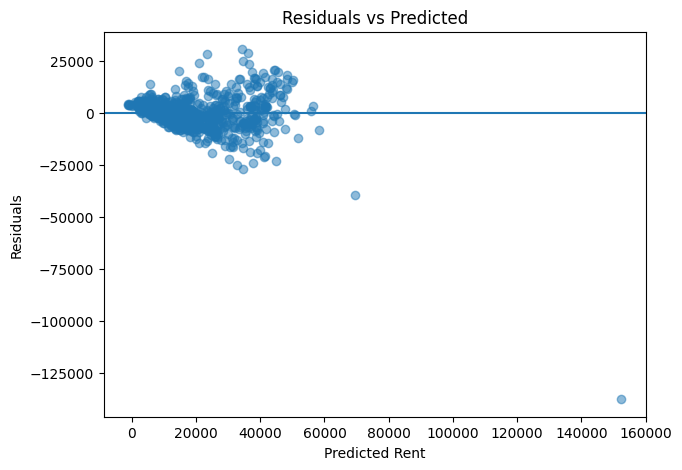

In [50]:
plt.figure(figsize=(7,5))
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(0)
plt.xlabel("Predicted Rent")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

In [51]:
error_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_test_pred,
    'Residual': residuals
})

error_df['Abs_Error'] = abs(error_df['Residual'])

error_df = error_df.sort_values(by='Abs_Error', ascending=False)

error_df.head(5)

,Actual,Predicted,Residual,Abs_Error
4653,15000,152446.553760,-137446.553760,137446.553760
275,30000,69400.541860,-39400.541860,39400.541860
3962,65000,34268.520777,30731.479223,30731.479223
3520,65000,36288.267541,28711.732459,28711.732459
2512,52000,23510.739444,28489.260556,28489.260556


In [52]:
X_test_copy = X_test.copy()
X_test_copy['Actual'] = y_test
X_test_copy['Predicted'] = y_test_pred
X_test_copy['Residual'] = residuals
X_test_copy['Abs_Error'] = abs(residuals)

In [53]:
X_test_copy.groupby('BHK')['Abs_Error'].mean()

,Abs_Error
BHK,
1,4233.068754
2,4411.773275
3,7909.472681
4,10195.347693
5,8258.760419
6,9147.933229


In [54]:
city_cols = [col for col in X_test_copy.columns if 'City_' in col]

X_test_copy['City'] = X_test_copy[city_cols].idxmax(axis=1)

X_test_copy.groupby('City')['Abs_Error'].mean()

,Abs_Error
City,
City_Chennai,3953.086120
City_Delhi,6068.558765
City_Hyderabad,5541.300600
City_Kolkata,3972.455758
City_Mumbai,8050.016089


Модель лінійної регресії продемонструвала задовільну якість прогнозування орендної плати та адекватну узагальнюючу здатність. Основними факторами, що впливають на вартість оренди, є площа житла та кількість кімнат.

Отримані результати свідчать про коректне проходження повного циклу задачі машинного навчання: від аналізу даних до оцінки якості моделі.